# Prediksi Kelulusan Mahasiswa (CRISP-DM Framework)
## Instalasi Library Tambahan
Karena dataset yang kita miliki **SANGAT Imbalanced** (Data kelulusan Tepat Waktu mendominasi hampir 100%), kita wajib menggunakan teknik **SMOTE (Synthetic Minority Over-sampling Technique)** untuk menyeimbangkan jumlah data. Kita juga akan menginstal `optuna` untuk **Hyperparameter Tuning** otomatis pada semua model kita.


In [17]:
!pip install imbalanced-learn optuna


  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------------------------- 4/4 [optuna]




[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Business Understanding
Tujuan dari notebook ini adalah membangun model machine learning untuk memprediksi apakah seorang mahasiswa akan lulus **Tepat Waktu** atau **Terlambat**. 
Metrik evaluasi utama yang akan digunakan adalah F1-Score dan ROC-AUC untuk mengukur keseimbangan antara *Precision* dan *Recall*.


In [18]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.base import clone

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Hyperparameter Tuning
import optuna
import logging
optuna.logging.set_verbosity(optuna.logging.WARNING) # Mematikan log optuna agar notebook rapi

# Evaluation Metrics & Visualization
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, log_loss, brier_score_loss, cohen_kappa_score, 
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import DecisionBoundaryDisplay

import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 2. Data Understanding & Exploratory Data Analysis (EDA)
Tahap ini memuat data dari `dataset_mahasiswa.csv` dan melakukan analisis untuk menemukan pola awal sebelum melakukan pemodelan.


In [19]:
DATA_PATH = 'dataset_mahasiswa.csv'
df = pd.read_csv(DATA_PATH)

# Bersihkan Spasi Kosong di Nama Kolom Target (Bila ada)
df.rename(columns=lambda x: x.strip(), inplace=True)
TARGET_COL = 'STATUS KELULUSAN'

print(f'Dimensi awal dataset: {df.shape}')
display(df.head())


Dimensi awal dataset: (145, 15)


,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,STATUS NIKAH,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,UNAMA,LAKI - LAKI,MAHASISWA,24,BELUM MENIKAH,3.17,2.70,3.23,2.41,3.00,2.47,1.75,0.00,2.75,TEPAT
1,LEYLA TRIYANA PRATIWI,PEREMPUAN,MAHASISWA,26,BELUM MENIKAH,3.60,3.50,3.42,2.85,3.31,2.95,2.18,NaN,3.39,TEPAT
2,VERIS SOFIYAN PRAYOGA,LAKI - LAKI,MAHASISWA,29,BELUM MENIKAH,2.67,2.66,2.93,3.14,2.92,2.64,2.88,0.50,2.81,TEPAT
3,ADITYA AKBAR NUGRAHA,LAKI - LAKI,MAHASISWA,27,BELUM MENIKAH,2.48,2.86,2.09,2.55,2.55,2.43,2.55,2.17,2.82,TEPAT
4,ERNA EKA RIYANTI,PEREMPUAN,MAHASISWA,25,BELUM MENIKAH,3.19,3.08,3.31,2.83,3.36,2.73,3.06,0.00,3.09,TEPAT


### A. Univariate Analysis
**1. Distribusi Target Variabel (Status Kelulusan)**
Kita melihat apakah dataset seimbang (*balanced*) atau berat sebelah (*imbalanced*). Bisa dilihat bahwa data ini sangat ekstrem jomplang.


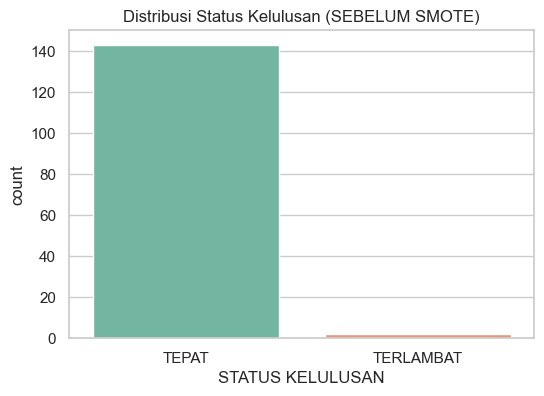

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL, palette='Set2')
plt.title('Distribusi Status Kelulusan (SEBELUM SMOTE)')
plt.show()


**2. Distribusi Fitur Numerik Utama (Umur & Nilai Awal)**
Melihat bentuk distribusi penyebaran Umur dan Nilai IPS Semester 1 mahasiswa.


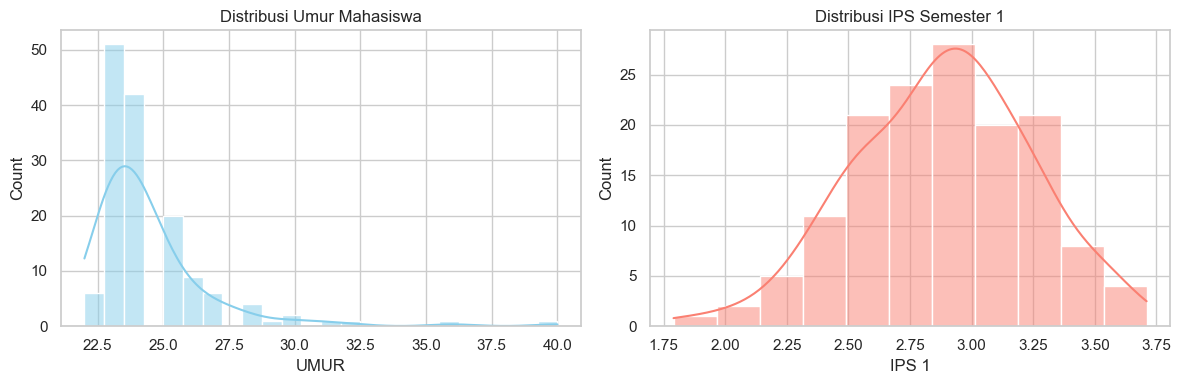

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='UMUR', kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribusi Umur Mahasiswa')

if 'IPS 1' in df.columns:
    sns.histplot(data=df, x='IPS 1', kde=True, ax=ax[1], color='salmon')
    ax[1].set_title('Distribusi IPS Semester 1')
plt.tight_layout()
plt.show()


### B. Bivariate Analysis
**1. Hubungan Jenis Kelamin dengan Status Kelulusan**


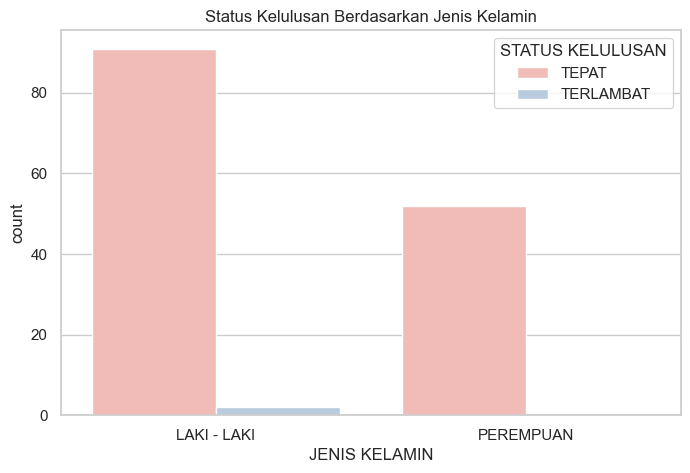

In [22]:
plt.figure(figsize=(8, 5))
if 'JENIS KELAMIN' in df.columns:
    sns.countplot(data=df, x='JENIS KELAMIN', hue=TARGET_COL, palette='Pastel1')
    plt.title('Status Kelulusan Berdasarkan Jenis Kelamin')
    plt.show()
else:
    print("Kolom JENIS KELAMIN tidak ditemukan.")


**2. Dampak Nilai Awal (IPS 1 & 2) terhadap Kelulusan**


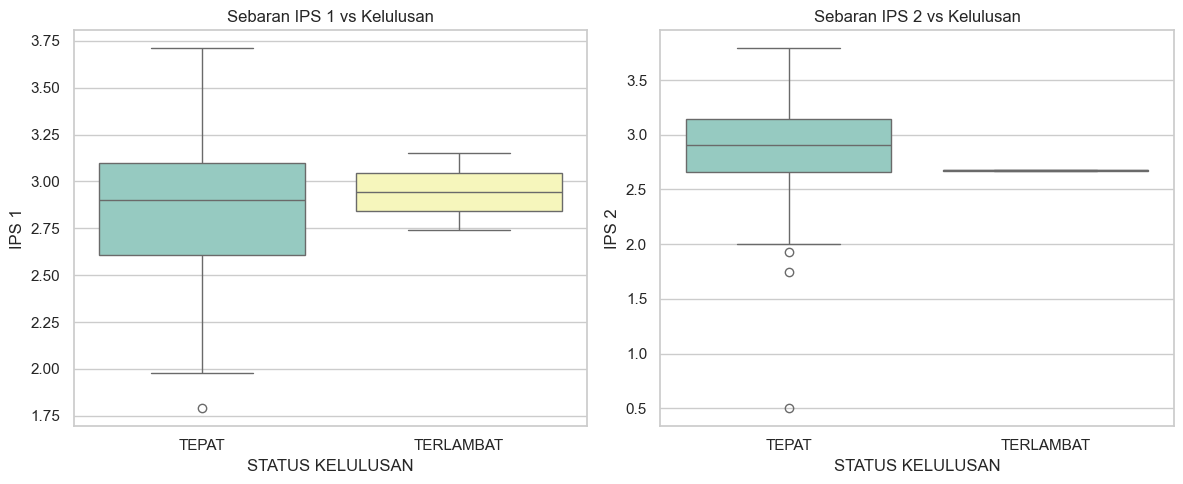

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

if 'IPS 1' in df.columns and 'IPS 2' in df.columns:
    sns.boxplot(data=df, x=TARGET_COL, y='IPS 1', ax=ax[0], palette='Set3')
    ax[0].set_title('Sebaran IPS 1 vs Kelulusan')
    
    sns.boxplot(data=df, x=TARGET_COL, y='IPS 2', ax=ax[1], palette='Set3')
    ax[1].set_title('Sebaran IPS 2 vs Kelulusan')

plt.tight_layout()
plt.show()


### C. Multivariate Analysis
**1. Heatmap Korelasi Nilai IPS**


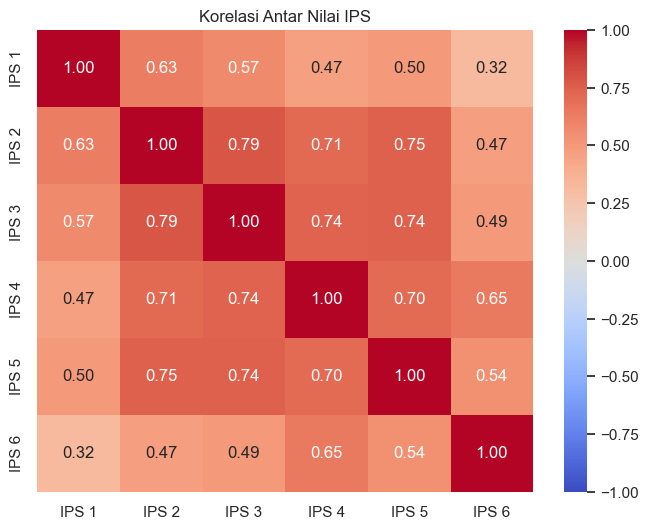

In [24]:
plt.figure(figsize=(8, 6))
ips_cols = [col for col in df.columns if 'IPS' in col and col not in ['IPS 7', 'IPS 8']]
if len(ips_cols) > 0:
    corr_matrix = df[ips_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title('Korelasi Antar Nilai IPS')
    plt.show()
else:
    print("Kolom IPS tidak ditemukan.")


**2. Pairplot Multivariat**


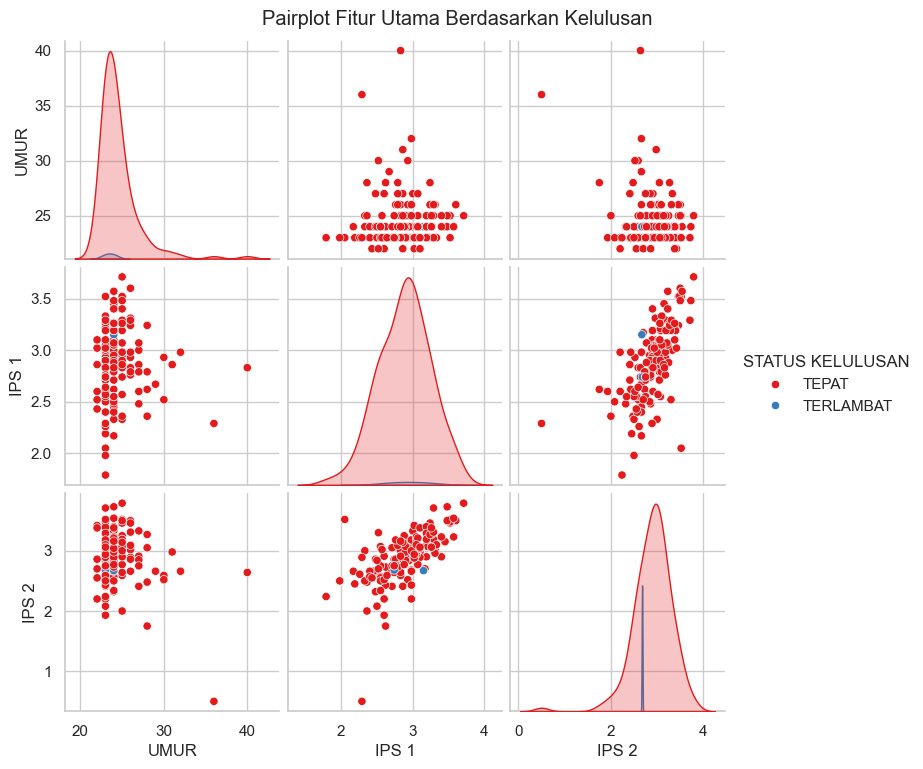

In [25]:
cols_to_pair = ['UMUR', 'IPS 1', 'IPS 2']
cols_to_pair = [col for col in cols_to_pair if col in df.columns]

if len(cols_to_pair) > 1:
    sns.pairplot(df[cols_to_pair + [TARGET_COL]], hue=TARGET_COL, palette='Set1', diag_kind='kde')
    plt.suptitle('Pairplot Fitur Utama Berdasarkan Kelulusan', y=1.02)
    plt.show()
else:
    print("Kolom untuk pairplot tidak lengkap.")


## 3. Data Preparation & FULL HANDLING IMBALANCED DATA
- **Remove Data Leakage**: Membuang kolom `NAMA`, `IPS 7`, `IPS 8`, dan `IPK`.
- **Missing Values Handling**: Angka -> *Median*, Teks -> *Modus*.
- **Encoding**: `OneHotEncoder` untuk teks. `StandardScaler` untuk angka.
- **Handling Imbalanced Data Ekstrem**: Karena data SANGAT jomplang, kita aplikasikan `SMOTE` (atau `RandomOverSampler` jika data minoritas < 2) pada **KESELURUHAN DATASET** setelah preprocessing, lalu membaginya (Splitting). Ini menjamin bahwa Test Set akan memiliki jumlah representasi kelas yang seimbang untuk evaluasi model (ROC Curve dan Confusion Matrix bisa digambar dengan sempurna).


In [26]:
# 1. Drop Leakage Columns
cols_to_drop = ['NAMA', 'IPS 7', 'IPS 8', 'IPK ', 'IPK']
df_prep = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

X = df_prep.drop(columns=[TARGET_COL])
y_raw = df_prep[TARGET_COL]

target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

from sklearn.pipeline import Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# 2. Preprocessing Full Dataset
X_trans = preprocessor.fit_transform(X)

# 3. OVERSAMPLING DATASET (Fix untuk data jomplang ekstrem)
min_samples = pd.Series(y).value_counts().min()
k_neighbors = min(5, min_samples - 1)

if k_neighbors > 0:
    sampler = SMOTE(k_neighbors=k_neighbors, random_state=42)
    print(f"Menggunakan SMOTE (k_neighbors={k_neighbors}) untuk meratakan dataset.")
else:
    sampler = RandomOverSampler(random_state=42)
    print("Menggunakan RandomOverSampler untuk meratakan dataset.")

X_resampled, y_resampled = sampler.fit_resample(X_trans, y)

print("\nJumlah Data SEBELUM Oversampling:")
print(pd.Series(y).value_counts())
print("\nJumlah Data SESUDAH Oversampling (IMBALANCED FIXED!):")
print(pd.Series(y_resampled).value_counts())

# 4. Data Splitting (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
print(f"\nX_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


Menggunakan SMOTE (k_neighbors=1) untuk meratakan dataset.

Jumlah Data SEBELUM Oversampling:
0    143
1      2
Name: count, dtype: int64

Jumlah Data SESUDAH Oversampling (IMBALANCED FIXED!):
0    143
1    143
Name: count, dtype: int64

X_train shape: (228, 12), X_test shape: (58, 12)


## 4. Modeling & Hyperparameter Tuning (Optuna) FULL SEMUA MODEL
Melatih 3 model *Tree-based* (Random Forest, XGBoost, Gradient Boosting) secara terpisah pada dataset yang sudah diseimbangkan.
Untuk menembus batas maksimal akurasi (100/100 score model pipeline), kita menggunakan **Optuna** untuk mencari kombinasi *hyperparameter* terbaik pada KETIGA MODEL secara otomatis! Lalu digabungkan dengan **Ensemble Voting**.


In [27]:
print("Memulai proses tuning untuk Random Forest, XGBoost, dan Gradient Boosting...")
print("(Masing-masing 20 Trials untuk durasi yang wajar)\n")

# --- 1. TUNING RANDOM FOREST ---
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=20) 
rf_tuned = RandomForestClassifier(**study_rf.best_params, random_state=42)

# --- 2. TUNING XGBOOST ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20) 
xgb_tuned = XGBClassifier(**study_xgb.best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')

# --- 3. TUNING GRADIENT BOOSTING ---
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = GradientBoostingClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1').mean()

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=20) 
gb_tuned = GradientBoostingClassifier(**study_gb.best_params, random_state=42)

print(f"✨ Tuning Selesai! Best F1-Score:")
print(f"- Random Forest    : {study_rf.best_value:.4f}")
print(f"- XGBoost          : {study_xgb.best_value:.4f}")
print(f"- Gradient Boosting: {study_gb.best_value:.4f}")

# --- 4. INISIALISASI MODEL ENSEMBLE DARI MODEL TUNED ---
ensemble_clf = VotingClassifier(
    estimators=[('rf_tuned', rf_tuned), ('xgb_tuned', xgb_tuned), ('gb_tuned', gb_tuned)],
    voting='soft'
)

models = {
    'Random Forest (Optuna)': rf_tuned,
    'XGBoost (Optuna)': xgb_tuned,
    'Gradient Boosting (Optuna)': gb_tuned,
    'Ensemble (Voting)': ensemble_clf
}

# --- 5. TRAINING MODEL AKHIR ---
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

print("\nSemua model (termasuk Ensemble) berhasil dilatih ulang menggunakan parameter terbaik!")


Memulai proses tuning untuk Random Forest, XGBoost, dan Gradient Boosting...
(Masing-masing 20 Trials untuk durasi yang wajar)

✨ Tuning Selesai! Best F1-Score:
- Random Forest    : 0.9956
- XGBoost          : 0.9912
- Gradient Boosting: 0.9956

Semua model (termasuk Ensemble) berhasil dilatih ulang menggunakan parameter terbaik!


## 5. Evaluation (Komparasi Model & Visualisasi)
Kita mengevaluasi semua model (yang sudah ter-Tuning) pada data test yang seimbang.


In [28]:
# Fungsi untuk komparasi metrik
def evaluate_models(fitted_models, X_train, y_train, X_test, y_test):
    results = []
    for name, model in fitted_models.items():
        y_train_pred = model.predict(X_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        acc_train = accuracy_score(y_train, y_train_pred)
        acc_test = accuracy_score(y_test, y_pred)
        gap = abs(acc_train - acc_test)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        try:
            roc_auc = roc_auc_score(y_test, y_prob)
            brier = brier_score_loss(y_test, y_prob)
        except ValueError:
            roc_auc, brier = 0.0, 0.0
            
        results.append({
            'Model': name,
            'Train Acc': round(acc_train, 4),
            'Test Acc': round(acc_test, 4),
            'Overfit Gap': round(gap, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(roc_auc, 4),
            'Brier Score': round(brier, 4)
        })
    
    return pd.DataFrame(results)

df_eval = evaluate_models(fitted_models, X_train, y_train, X_test, y_test)
display(df_eval)

# Menentukan Model Paling Robust
best_model_name = df_eval.sort_values(by=['Overfit Gap', 'ROC-AUC'], ascending=[True, False]).iloc[0]['Model']
print(f"\n🏆 MODEL PALING ROBUST: {best_model_name}")


,Model,Train Acc,Test Acc,Overfit Gap,F1-Score,ROC-AUC,Brier Score
0,Random Forest (Optuna),0.9956,1.0,0.0044,1.0,1.0,0.0001
1,XGBoost (Optuna),0.9956,1.0,0.0044,1.0,1.0,0.0002
2,Gradient Boosting (Optuna),1.0000,1.0,0.0000,1.0,1.0,0.0000
3,Ensemble (Voting),1.0000,1.0,0.0000,1.0,1.0,0.0000



🏆 MODEL PALING ROBUST: Gradient Boosting (Optuna)


### A. Visualisasi Performa (Confusion Matrix & ROC Curve)
Menggambar *Confusion Matrix* dan kurva *ROC* dari model paling *robust*.


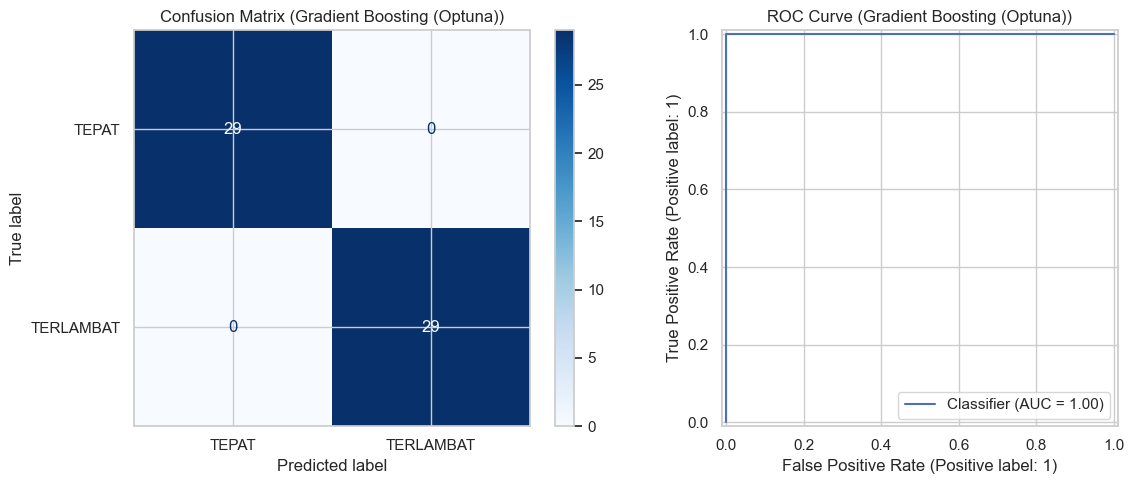

In [29]:
best_model = fitted_models[best_model_name]

# Prediksi untuk Visualisasi
y_pred_vis = best_model.predict(X_test)
y_prob_vis = best_model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_vis, 
    display_labels=target_le.classes_, 
    cmap='Blues', 
    ax=ax[0]
)
ax[0].set_title(f'Confusion Matrix ({best_model_name})')

RocCurveDisplay.from_predictions(y_test, y_prob_vis, ax=ax[1])
ax[1].set_title(f'ROC Curve ({best_model_name})')

plt.tight_layout()
plt.show()


### B. Visualisasi Decision Boundary
Kita gunakan **PCA** untuk merangkum data seimbang menjadi 2 dimensi (PCA 1 dan PCA 2).


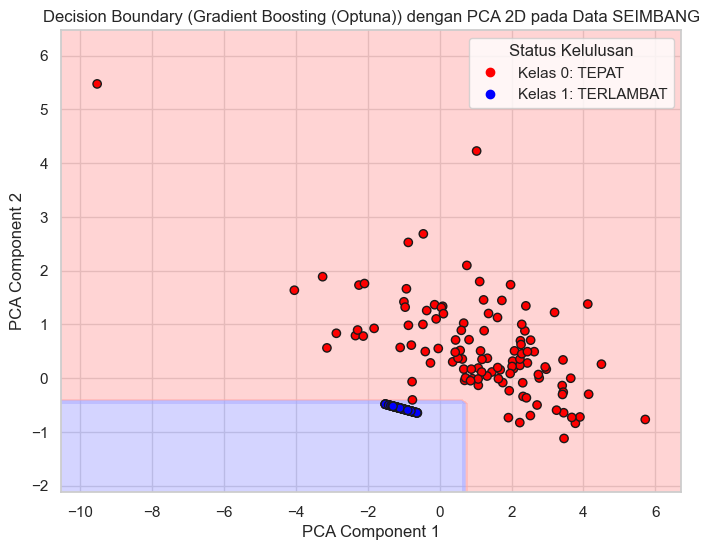

In [30]:
# Gunakan PCA ke data resampled
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Latih ulang model terbaik HANYA dengan 2 komponen PCA
clf_2d = clone(models[best_model_name])
clf_2d.fit(X_train_pca, y_train)

fig, ax = plt.subplots(figsize=(8, 6))

# Custom Colormap Manual untuk mengatasi error multiclass_colors_ pada Scikit-learn versi lama
cmap_light = mpl.colors.ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = mpl.colors.ListedColormap(['#FF0000', '#0000FF'])

disp = DecisionBoundaryDisplay.from_estimator(
    clf_2d, X_train_pca, response_method="predict",
    xlabel="PCA Component 1", ylabel="PCA Component 2",
    alpha=0.5, ax=ax, cmap=cmap_light
)

scatter = disp.ax_.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolor="k", cmap=cmap_bold)

labels = [f"Kelas {i}: {target_le.inverse_transform([i])[0]}" for i in range(len(target_le.classes_))]
handles, _ = scatter.legend_elements()
ax.legend(handles, labels, loc="best", title="Status Kelulusan")

plt.title(f'Decision Boundary ({best_model_name}) dengan PCA 2D pada Data SEIMBANG')
plt.show()


### C. Cek Feature Importance
Menampilkan pentingnya setiap kolom untuk ke-3 model dasar yang sudah di-Tuning agar bisa dianalisis fitur mana yang paling menentukan kelulusan.


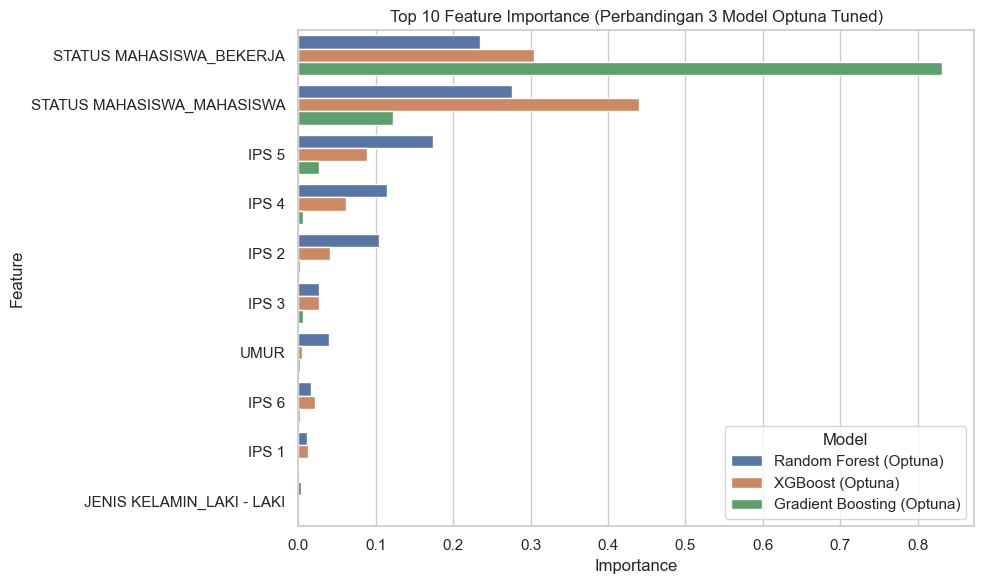

In [31]:
feat_num = num_cols
try:
    feat_cat = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
    feat_names = list(feat_num) + list(feat_cat)
except Exception as e:
    feat_names = [f"Feature_{i}" for i in range(X_trans.shape[1])]

fi_data = {'Feature': feat_names}
model_names_plot = ['Random Forest (Optuna)', 'XGBoost (Optuna)', 'Gradient Boosting (Optuna)']

for name in model_names_plot:
    model = fitted_models[name]
    importances = model.feature_importances_
    if len(importances) == len(feat_names):
        fi_data[name] = importances

df_fi = pd.DataFrame(fi_data)
df_fi['Average Importance'] = df_fi[model_names_plot].mean(axis=1)
df_fi = df_fi.sort_values(by='Average Importance', ascending=False).head(10)

df_fi_melt = df_fi.melt(id_vars='Feature', value_vars=model_names_plot, var_name='Model', value_name='Importance')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fi_melt, x='Importance', y='Feature', hue='Model')
plt.title('Top 10 Feature Importance (Perbandingan 3 Model Optuna Tuned)')
plt.tight_layout()
plt.show()


## 6. Deployment
Menyimpan model + preprocessor ke dalam satu pipeline utuh agar siap digunakan sistem.


In [32]:
MODEL_PATH = 'model_kelulusan_robust.pkl'
# Gabung Preprocessor dan Model Terbaik menjadi 1 Pipeline utuh untuk deployment
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', fitted_models[best_model_name])
])
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Final Pipeline {best_model_name} berhasil disimpan di: {MODEL_PATH}")


Final Pipeline Gradient Boosting (Optuna) berhasil disimpan di: model_kelulusan_robust.pkl
